# Experimento A/B: conversión de una landing page
**Mario Alberto Vivero · Proyecto académico**

Evaluación de la versión B frente a A a partir de conteos guardados en el notebook original. Esta revisión puede reproducir las pruebas de conversión; no reproduce la prueba de gasto ni el QA de registros individuales sin `landing_experiment.csv`.


In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, norm, chisquare
ROOT = Path.cwd()
if not (ROOT / 'data').is_dir(): ROOT = ROOT.parent
counts = json.loads((ROOT / 'data/conteos_observados.json').read_text())
tables = {key: pd.DataFrame.from_dict(counts[key], orient='index', columns=counts['columns'])
          for key in ['landing','traffic_source','user_type']}
for key, table in tables.items():
    assert table.to_numpy().sum() == 40000
    assert table['convirtio'].sum() == 5706
    print(key, '\n', table)


landing 
    no_convirtio  convirtio
A         17470       2512
B         16824       3194
traffic_source 
           no_convirtio  convirtio
Ads              10176       1759
Email             5205        918
Organic          15507       2480
Referral          3406        549
user_type 
             no_convirtio  convirtio
Nuevo              22295       3738
Recurrente         11999       1968


## Conversión: magnitud y precisión
Comparación bilateral A/B. Se conserva la corrección de continuidad de la prueba chi-cuadrada original para tablas 2×2. El intervalo de diferencia de proporciones usa una aproximación normal no agrupada; describe incertidumbre muestral bajo independencia.


In [2]:
landing = tables['landing']
n = landing.sum(axis=1)
p = landing['convirtio'] / n
diff = p['B'] - p['A']
se = math.sqrt(p['A']*(1-p['A'])/n['A'] + p['B']*(1-p['B'])/n['B'])
lo, hi = diff - norm.ppf(.975)*se, diff + norm.ppf(.975)*se
chi, pv, dof, expected = chi2_contingency(landing)
print(f'A: {p["A"]:.2%}; B: {p["B"]:.2%}')
print(f'Diferencia B−A: {diff*100:.2f} puntos porcentuales')
print(f'Incremento relativo: {diff/p["A"]:.2%}')
print(f'IC 95% aproximado: [{lo*100:.2f}, {hi*100:.2f}] puntos porcentuales')
print(f'Chi²: {chi:.4f}; p: {pv:.4e}; frecuencia esperada mínima: {expected.min():.1f}')
print('Diferencia de conteos observados:', int(landing.loc['B','convirtio']-landing.loc['A','convirtio']))
print(f'Proyección a igual exposición de {n["B"]} usuarios: {diff*n["B"]:.1f} conversiones')


A: 12.57%; B: 15.96%
Diferencia B−A: 3.38 puntos porcentuales
Incremento relativo: 26.92%
IC 95% aproximado: [2.70, 4.07] puntos porcentuales
Chi²: 93.3748; p: 4.3272e-22; frecuencia esperada mínima: 2850.4
Diferencia de conteos observados: 682
Proyección a igual exposición de 20018 usuarios: 677.5 conversiones


B registra 15.96% frente a 12.57% en A: +3.38 puntos porcentuales y +26.92% relativo. Los 682 corresponden a 3194−2512 conversiones observadas con tamaños de grupo diferentes. Aplicar la diferencia de tasas a 20018 usuarios da aproximadamente 677 conversiones: es una proyección bajo tasas constantes, no un resultado causal observado independiente.


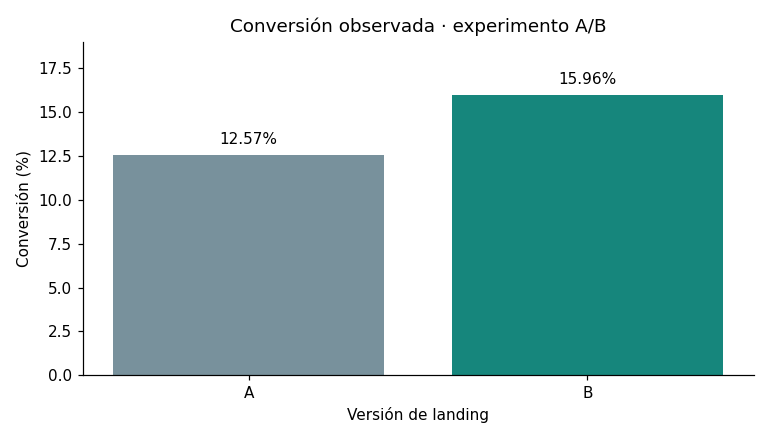

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
bars=ax.bar(p.index, p.values*100, color=['#78919c','#16867c'])
ax.bar_label(bars, labels=[f'{x:.2%}' for x in p], padding=5)
ax.set(ylim=(0,19), ylabel='Conversión (%)', xlabel='Versión de landing', title='Conversión observada · experimento A/B')
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
fig.savefig(ROOT / 'images/conversion_ab.png', dpi=160)
plt.show()


## Canales y tipos de usuario
Son comparaciones marginales, agrupando A y B. No miden si el efecto de B cambia por segmento. Los canales no fueron asignados aleatoriamente y una diferencia de conversión no demuestra mayor rentabilidad publicitaria.


In [4]:
for key in ['traffic_source','user_type']:
    table=tables[key]
    chi,pv,dof,expected=chi2_contingency(table)
    summary=table.copy()
    summary['total']=table.sum(axis=1)
    summary['conversion_pct']=100*table['convirtio']/summary['total']
    print(key, '\n', summary.round(4).to_string())
    print(f'Chi²={chi:.4f}; p={pv:.6f}; gl={dof}; esperado mínimo={expected.min():.2f}')


traffic_source 
           no_convirtio  convirtio  total  conversion_pct
Ads              10176       1759  11935         14.7382
Email             5205        918   6123         14.9927
Organic          15507       2480  17987         13.7877
Referral          3406        549   3955         13.8812
Chi²=8.6621; p=0.034138; gl=3; esperado mínimo=564.18
user_type 
             no_convirtio  convirtio  total  conversion_pct
Nuevo              22295       3738  26033         14.3587
Recurrente         11999       1968  13967         14.0904
Chi²=0.5135; p=0.473634; gl=1; esperado mínimo=1992.39


Email (14.99%) y Ads (14.74%) tienen las mayores tasas observadas. Organic es 13.79%, no 13.70%. La prueba global de canales da p = 0.0341 sin ajuste; no identifica qué pares difieren ni justifica cambios de presupuesto sin costos y valor de clientes.

Nuevos: 14.36%; recurrentes: 14.09%; p = 0.4736. No se rechaza independencia a nivel 0.05; esto no prueba equivalencia ni descarta el valor de campañas segmentadas.


## Comprobaciones adicionales de revisión
El reparto esperado 50/50 no está documentado. La siguiente prueba es condicional a ese supuesto y no certifica aleatorización. También se muestra un ajuste Holm ilustrativo para las dos pruebas exploratorias de segmentación como una familia; esa familia no fue preespecificada en el original.


In [5]:
print('SRM bajo supuesto 50/50:', chisquare(n.to_numpy(), f_exp=[20000,20000]))
ps = {key: chi2_contingency(tables[key])[1] for key in ['traffic_source','user_type']}
ordered=sorted(ps, key=ps.get)
running=0
for rank,key in enumerate(ordered):
    running=max(running,min(1,(len(ordered)-rank)*ps[key]))
    print(f'Holm ilustrativo {key}: p ajustado={running:.6f}')


SRM bajo supuesto 50/50: Power_divergenceResult(statistic=np.float64(0.0324), pvalue=np.float64(0.8571525681981985))
Holm ilustrativo traffic_source: p ajustado=0.068275
Holm ilustrativo user_type: p ajustado=0.473634


Con esta familia ilustrativa, canales tiene p ajustado ≈0.0683 y no supera el umbral 0.05. Las conclusiones exploratorias deben distinguirse del contraste principal A/B. El chequeo 50/50 no detecta desequilibrio de tamaños (p ≈0.857), pero no valida balance de características, independencia ni implementación de la asignación.

## Gasto: resultado histórico y limitación
El original aplica `ttest_ind` con varianzas iguales por defecto exclusivamente a compradores (2512 en A, 3194 en B): t = −9.3656, p mostrado como 0.0000 por redondeo. No significa probabilidad cero. No se guardaron las medias y varianzas por grupo necesarias para recalcular esa prueba, un intervalo o el tamaño de la diferencia.

Seleccionar solo compradores condiciona el análisis en una variable posterior al tratamiento. Por eso no equivale al gasto por usuario asignado ni demuestra que B cause mayor gasto. Con los microdatos debe analizarse gasto de todos los usuarios, incluidos ceros, y revisar supuestos; el archivo complementario propone Welch y explicita este cambio.

## Recomendación
La evidencia de conversión favorece B. Recomendar un despliegue gradual condicionado a validar asignación, integridad del experimento y métricas de negocio como gasto por usuario asignado, costos y devoluciones. No modificar presupuestos por canal ni descartar segmentación solo con estas pruebas marginales.
